# Random Forest Model: Daily PM2.5 Prediction Using Lag Features and Seasonal Encoding
## Objective
Build a tree-based model (Random Forest) to predict daily PM2.5 using the same features as the baseline:
- Lagged PM2.5 (lag1, lag7, rolling mean)
- Season (one-hot encoding)

We evaluate using MAE, RMSE, R², and MAPE with the same time-based split to compare fairly against Linear Regression and the Naive baseline.

In [30]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

## 1) Load Data

In [31]:
df = pd.read_csv("../../data/master/PM25_2020 cleaned Master_20_23.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["City", "Date"]).reset_index(drop=True)
df["PM25"] = pd.to_numeric(df["PM25"], errors="coerce")

## 2) Feature engineering (same as baseline)

In [32]:
df["PM25_lag1"] = df.groupby("City")["PM25"].shift(1)
df["PM25_lag7"] = df.groupby("City")["PM25"].shift(7)
df["PM25_roll7_mean"] = (
    df.groupby("City")["PM25"]
       .transform(lambda s: s.shift(1).rolling(7, min_periods=3).mean())
)

season_dummies = pd.get_dummies(df["Season"], prefix="Season", drop_first=True)
df = pd.concat([df, season_dummies], axis=1)
season_cols = list(season_dummies.columns)

feature_cols = ["PM25_lag1","PM25_lag7","PM25_roll7_mean"] + season_cols
model_df = df.dropna(subset=feature_cols + ["PM25"]).copy()
X = model_df[feature_cols]
y = model_df["PM25"]

## 3) Time-Based Split (80/20) 

In [33]:
cutoff = pd.Timestamp("2023-01-01")

train_df = model_df[model_df["Date"] < cutoff].copy()
test_df  = model_df[model_df["Date"] >= cutoff].copy()

X_train = train_df[feature_cols]
y_train = train_df["PM25"]
X_test  = test_df[feature_cols]
y_test  = test_df["PM25"]

## 4) Train Random Forest

In [34]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    max_depth=None
)
rf.fit(X_train, y_train)
y_pred_test = rf.predict(X_test)

## 5) Metrics

In [35]:
def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred_test = np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred_test[mask]) / y_true[mask])) * 100

mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2 = r2_score(y_test, y_pred_test)
mape_value = mape(y_test,y_pred_test)

print(f"Random Forest Results")
print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")
print(f"MAPE : {mape_value:.2f}%")

Random Forest Results
MAE  : 4.582
RMSE : 13.854
R²   : 0.522
MAPE : 67.13%


### Interpretation
The Random Forest model achieved an R² of 0.510, slightly lower than the linear regression baseline (R² = 0.536). 

This suggests that PM2.5 dynamics are largely driven by strong linear temporal dependence, particularly the previous day's concentration. While Random Forest can model nonlinear relationships, it did not substantially improve predictive accuracy in this case.

Therefore, the simpler linear regression model remains the preferred baseline model.

## 6) Plot

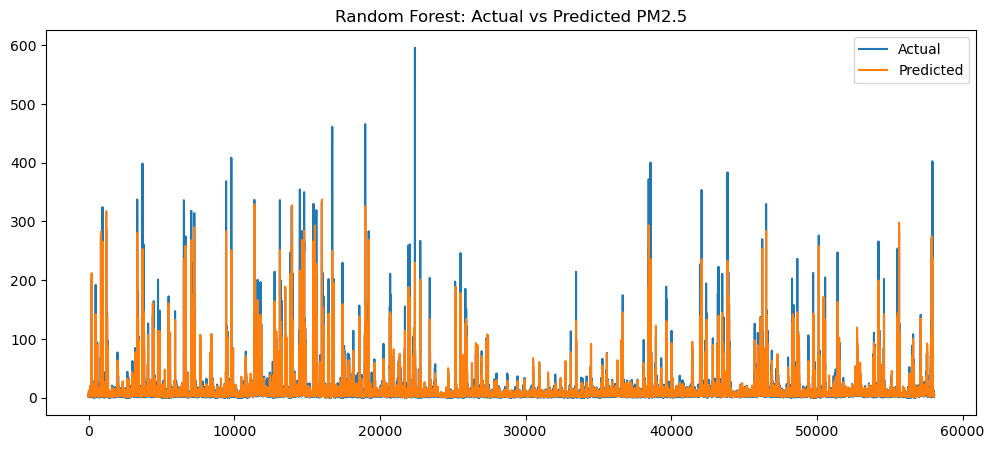

In [36]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_test, label="Predicted")
plt.legend()
plt.title("Random Forest: Actual vs Predicted PM2.5")
plt.show()

In [45]:
print(len(X_train.columns), len(rf.feature_importances_))

6 6


## 7) Feature Importance (interpretable for RF)

In [18]:
import pandas as pd
fi = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

fi.head(20)

,Feature,Importance
0,PM25_lag1,0.696834
2,PM25_roll7_mean,0.153511
1,PM25_lag7,0.127196
4,Season_Summer,0.013166
5,Season_Winter,0.006335
3,Season_Spring,0.002957


## Model Comparison Summary

In [20]:
comparison = pd.DataFrame([
    {"Model": "Naive (Lag1)", "MAE": 2.988, "RMSE": 7.885, "R2": 0.457},
    {"Model": "Linear Regression", "MAE": 2.808, "RMSE": 7.284, "R2": 0.536},
    {"Model": "Random Forest", "MAE": 2.956, "RMSE": 7.303, "R2": 0.510},
])

comparison

,Model,MAE,RMSE,R2
0,Naive (Lag1),2.988,7.885,0.457
1,Linear Regression,2.808,7.284,0.536
2,Random Forest,2.956,7.303,0.510


In [21]:
comparison.to_csv("../results/model_comparison_pm25.csv", index=False)